# Himawari-9 AHI L2 Cloud Products — GBR Workflow

This notebook demonstrates the complete pipeline for accessing Himawari-9 AHI Level-2 cloud products
from the NOAA Open Data bucket on AWS, subsetting to the **Great Barrier Reef (GBR) region**, and
working with the data as lazy xarray Datasets.

---

## Data overview

| Parameter | Value |
|---|---|
| Satellite | Himawari-9 (JAXA), operated by JMA |
| Sensor | Advanced Himawari Imager (AHI) |
| Products | CMSK (cloud mask), CHGT (cloud height), CPHS (cloud phase) |
| S3 bucket | `s3://noaa-himawari9` (anonymous public access) |
| Cadence | 10 minutes (full disk) |
| Grid | 5500 × 5500 pixels, 2 km at nadir, geostationary (SSP 140.7 °E) |
| File format | NetCDF4/HDF5, ~120 MB per file |

## GBR region of interest

| | |
|---|---|
| Longitude | 142–155 °E |
| Latitude | 10–25 °S |
| Pixel footprint | ~770 rows × 704 columns (≈6% of full disk) |

## Why kerchunk?

Each 5500×5500 float32 variable takes ~121 MB on disk, but the GBR region only covers ~3 MB of
HDF5 chunks (200×200 px each). Without kerchunk, opening a file with xarray streams the full 121 MB
even for a small spatial subset. With kerchunk we map every HDF5 chunk to its exact byte range in S3,
so xarray only fetches the ~20 chunks that overlap the GBR — a **40× data reduction**.

---

## Pipeline at a glance

```
S3 keys                                         s3://noaa-himawari9/AHI-L2-FLDK-Clouds/…
    │
    ▼  list_product_files()
Per-file S3 keys  ─────────────────────────────  [key1, key2, …, keyN]
    │
    ▼  build_references_parallel()           ←──  cached JSON files
Kerchunk refs     ─────────────────────────────  [{"refs": {"CloudMask/0.0": [url,off,len], …}}, …]
    │
    ▼  build_combined_reference()            ←──  cached Parquet store dir
Virtual Parquet   ─────────────────────────────  combined/{product}_{start}_{end}/ (*.parq)
    │
    ▼  open_virtual_dataset()  +  subset_to_gbr()
Lazy xr.Dataset   ─────────────────────────────  dims: (time=N, Rows=1170, Columns=1104)
    │
    ▼  .compute()   ← only now does S3 I/O happen
In-memory arrays
```

## 0  Environment setup

Import the module, configure logging so pipeline steps are visible, and set the local cache directory
where kerchunk JSON references and combined Parquet stores will be saved.

The cache is persistent across sessions — after the first run for a given time window the pipeline
reads everything from disk with no S3 metadata requests.

In [1]:
import logging
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Suppress routine HDF5/zarr encoding warnings (fill-value patch handles these)
warnings.filterwarnings("ignore")

# Show INFO-level pipeline progress in the notebook
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-7s  %(message)s",
    datefmt="%H:%M:%S",
)

# ── Import the pipeline functions ────────────────────────────────────────────
from himawari_gbr.access import (
    # Step-by-step API
    list_product_files,
    generate_reference,
    build_references_parallel,
    build_combined_reference,
    open_virtual_dataset,
    open_single_file,
    subset_to_gbr,
    compute_pixel_bounds,
    # High-level convenience wrapper
    load_gbr_cloud_data,
    # Useful constants
    GBR_LON, GBR_LAT,
    GBR_ROW_SLICE, GBR_COL_SLICE,
    PRODUCT_DATA_VARS,
)

# ── Cache directory ──────────────────────────────────────────────────────────
# JSON references and Parquet stores are saved here.  Change to a fast local SSD
# for best performance on large collections.
CACHE_DIR = Path("~/.cache/himawari-gbr").expanduser()
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Cache directory: {CACHE_DIR}")

Cache directory: /home/eklein/.cache/himawari-gbr


---
## 1  Listing available files on S3

### S3 path structure

```
s3://noaa-himawari9/AHI-L2-FLDK-Clouds/
    {YYYY}/
        {MM}/
            {DD}/
                {HHMM}/
                    AHI-CMSK_v1r1_h09_s{YYYYMMDDHHMM}_e{...}_c{...}.nc
                    AHI-CHGT_v1r1_h09_s{YYYYMMDDHHMM}_e{...}_c{...}.nc
                    AHI-CPHS_v1r1_h09_s{YYYYMMDDHHMM}_e{...}_c{...}.nc
```

Each 10-minute slot contains exactly **three files** — one per product.  `list_product_files()`
iterates over every 10-minute boundary in the requested window and calls `fs.ls()` on each slot
directory, filtering for the chosen product prefix.

The filename timestamp fields are:
- `s` — **scan start** (used as the time coordinate)
- `e` — scan end
- `c` — file creation time

In [2]:
# List all CMSK files for one hour on 1 January 2024 (UTC)
# The function snaps the start time back to the nearest 10-minute boundary.

START = datetime(2024, 1, 1,  0, 0)   # 00:00 UTC
END   = datetime(2024, 1, 1,  0, 50)  # through 00:50 UTC  → 6 slots

cmsk_keys = list_product_files("CMSK", START, END)

print(f"Found {len(cmsk_keys)} CMSK files\n")
for key in cmsk_keys:
    fname = key.split("/")[-1]
    print(f"  {fname}")

Found 6 CMSK files

  AHI-CMSK_v1r1_h09_s202401010000202_e202401010009396_c202401010018130.nc
  AHI-CMSK_v1r1_h09_s202401010010202_e202401010019396_c202401010028219.nc
  AHI-CMSK_v1r1_h09_s202401010020202_e202401010029396_c202401010038223.nc
  AHI-CMSK_v1r1_h09_s202401010030201_e202401010039395_c202401010049016.nc
  AHI-CMSK_v1r1_h09_s202401010040201_e202401010049395_c202401010058071.nc
  AHI-CMSK_v1r1_h09_s202401010050201_e202401010059395_c202401010108204.nc


In [3]:
# You can query multiple products at once — here we verify all three are present
# for the first slot and have the same timestamp prefix.

single_slot_start = datetime(2024, 1, 1, 0, 0)
single_slot_end   = datetime(2024, 1, 1, 0, 0)

for product in ("CMSK", "CHGT", "CPHS"):
    keys = list_product_files(product, single_slot_start, single_slot_end)
    print(f"{product}: {keys[0].split('/')[-1]}" if keys else f"{product}: NOT FOUND")

CMSK: AHI-CMSK_v1r1_h09_s202401010000202_e202401010009396_c202401010018130.nc
CHGT: AHI-CHGT_v1r1_h09_s202401010000202_e202401010009396_c202401010018130.nc
CPHS: AHI-CPHS_v1r1_h09_s202401010000202_e202401010009396_c202401010018130.nc


---
## 2  Kerchunk references: mapping HDF5 chunks to S3 byte ranges

### What is a kerchunk reference?

A kerchunk JSON reference is a lightweight (~2 MB) dictionary that maps every array chunk in an
HDF5/NetCDF4 file to a byte-range in the original S3 object:

```json
{
  "version": 1,
  "refs": {
    ".zgroup": "{}",
    "CloudMask/.zarray": "{\"shape\": [5500, 5500], \"chunks\": [200, 200], ...}",
    "CloudMask/.zattrs": "{\"_ARRAY_DIMENSIONS\": [\"Rows\", \"Columns\"], ...}",
    "CloudMask/0.0": ["s3://noaa-himawari9/.../AHI-CMSK_...nc", 12345678, 40000],
    "CloudMask/0.1": ["s3://noaa-himawari9/.../AHI-CMSK_...nc", 12385678, 40000],
    ...
  }
}
```

Each `[url, offset, length]` triple is a **HTTP Range request** — fsspec will issue
`GET /key HTTP/1.1\nRange: bytes=offset–(offset+length-1)` to fetch just that chunk.

For a 5500×5500 array with 200×200 chunks there are **784 chunks per variable**.  The GBR region
spans ~6 row-chunks × ~6 col-chunks = **≈36 chunks per variable**, regardless of whether we read
1 time step or 144 (a full day).

### Zarr compatibility patch

These HDF5 files store `_FillValue` attributes as 1-element NumPy arrays rather than scalars.
zarr ≥2.17 `encode_fill_value()` requires a Python scalar and raises `TypeError`, causing kerchunk
to silently skip the affected variable. `access.py` applies a one-line monkey-patch at import time
to fix this.

In [4]:
# Generate (or load cached) a kerchunk JSON reference for one file.
# On first call this downloads ~2 MB of HDF5 metadata from S3 and saves a JSON.
# On subsequent calls the JSON is read from disk instantly.

first_key = cmsk_keys[0]
ref_path = generate_reference(first_key, CACHE_DIR)

print(f"Reference file: {ref_path}")
print(f"File size:      {ref_path.stat().st_size / 1024:.0f} KB")

Reference file: /home/eklein/.cache/himawari-gbr/refs/AHI-L2-FLDK-Clouds/2024/01/01/0000/AHI-CMSK_v1r1_h09_s202401010000202_e202401010009396_c202401010018130.json
File size:      1945 KB


In [5]:
import json
from collections import Counter

with open(ref_path) as f:
    refs = json.load(f)

all_keys = list(refs["refs"].keys())
print(f"Total reference entries : {len(all_keys)}")

# Count entries per variable
prefix_counts = Counter(k.split("/")[0] for k in all_keys)
spatial_vars = {v: n for v, n in prefix_counts.items() if n > 5}  # 5+ entries = chunked array
scalar_vars  = {v: n for v, n in prefix_counts.items() if n <= 5}

print(f"\nChunked 2-D variables ({len(spatial_vars)}):")
for var, n in sorted(spatial_vars.items(), key=lambda x: -x[1]):
    n_chunks = n - 2  # subtract .zarray and .zattrs
    print(f"  {var:<30s}: {n_chunks:4d} chunks")

print(f"\nChunk key format example: {[k for k in all_keys if k.startswith('CloudMask/') and '.' in k][0]}")

Total reference entries : 11852

Chunked 2-D variables (15):
  CloudMask                     :  784 chunks
  CloudMaskBinary               :  784 chunks
  CloudMaskBinaryAWIPS          :  784 chunks
  CloudMaskPacked               :  784 chunks
  CloudMaskQualFlag             :  784 chunks
  CloudMaskQualFlagAWIPS        :  784 chunks
  CloudProbability              :  784 chunks
  ClrSkyOBS_RTM                 :  784 chunks
  Dust_Mask                     :  784 chunks
  Fire_Mask                     :  784 chunks
  IceCloudProbability           :  784 chunks
  Latitude                      :  784 chunks
  Longitude                     :  784 chunks
  PhaseUncertainty              :  784 chunks
  Smoke_Mask                    :  784 chunks

Chunk key format example: CloudMask/.zarray


---
## 3  Opening a single file as a lazy xarray Dataset

`open_single_file()` calls `generate_reference()` internally (caching the JSON) and then opens the
file via `fsspec.ReferenceFileSystem` → zarr mapper → `xr.open_dataset(..., engine='zarr')`.

The key parameter `chunks={}` tells xarray to use **Dask** for all arrays.  Every variable is a Dask
graph node — no data is downloaded until you call `.compute()`, `.values`, or trigger a plot.

You can ask for a subset of variables to avoid opening array metadata for variables you don't need.

In [6]:
# Open the first CMSK file.  Only the requested variables are opened.
ds_full = open_single_file(
    first_key,
    CACHE_DIR,
    variables=["CloudMask", "CloudProbability", "CloudMaskQualFlag",
               "Latitude", "Longitude"],
)

print(ds_full)
print("\nDims:", dict(ds_full.dims))
print("Vars:", list(ds_full.data_vars))

10:09:15  INFO     Read reference from URL /home/eklein/.cache/himawari-gbr/refs/AHI-L2-FLDK-Clouds/2024/01/01/0000/AHI-CMSK_v1r1_h09_s202401010000202_e202401010009396_c202401010018130.json
10:09:16  INFO     Read reference from URL /home/eklein/.cache/himawari-gbr/refs/AHI-L2-FLDK-Clouds/2024/01/01/0000/AHI-CMSK_v1r1_h09_s202401010000202_e202401010009396_c202401010018130.json
10:09:16  INFO     Read reference from URL /home/eklein/.cache/himawari-gbr/refs/AHI-L2-FLDK-Clouds/2024/01/01/0000/AHI-CMSK_v1r1_h09_s202401010000202_e202401010009396_c202401010018130.json


<xarray.Dataset> Size: 605MB
Dimensions:            (Rows: 5500, Columns: 5500)
Coordinates:
    Latitude           (Rows, Columns) float32 121MB dask.array<chunksize=(200, 200), meta=np.ndarray>
    Longitude          (Rows, Columns) float32 121MB dask.array<chunksize=(200, 200), meta=np.ndarray>
Dimensions without coordinates: Rows, Columns
Data variables:
    CloudMask          (Rows, Columns) float32 121MB dask.array<chunksize=(200, 200), meta=np.ndarray>
    CloudProbability   (Rows, Columns) float32 121MB dask.array<chunksize=(200, 200), meta=np.ndarray>
    CloudMaskQualFlag  (Rows, Columns) float32 121MB dask.array<chunksize=(200, 200), meta=np.ndarray>
Attributes: (12/36)
    Conventions:                               CF-1.6
    ECM_LUT_NAME:                              v2.0/ecm2_abhi_ops_global_opt.nc
    ECM_PRIOR_NAME:                            v2.0/nb_cloud_mask_modis_prior...
    Metadata_Conventions:                      CF-1.6, Unidata Dataset Discov...
    Metadata_L

### File coordinate system

The arrays use **image coordinates** (`Rows`, `Columns`) rather than geographic coordinates, because
the satellite measures in scan-angle space, not lat/lon space.  The 2-D `Latitude` and `Longitude`
arrays encode the geographic position of each pixel but are **not** used as xarray dimension
coordinates (they're stored as regular data variables).

| Dimension | Size | Meaning |
|---|---|---|
| `Rows` | 5500 | North–South scan lines (row 0 = ~81 °N, row 5499 = ~81 °S) |
| `Columns` | 5500 | West–East scan columns (col 0 = ~59 °W, col 5499 = ~180 °E) |

The sub-satellite point is at **row 2750, column 2750** (SSP = 140.71 °E, ~0 °N).

### CloudMask flag values

| Value | Meaning |
|---|---|
| 0 | Clear |
| 1 | Probably clear |
| 2 | Probably cloudy |
| 3 | Cloudy |
| -128 | Fill (no data / off-disk) |

---
## 4  Spatially subsetting to the GBR bounding box

### Pre-computed pixel bounds

Converting the geographic bounding box to pixel indices must happen **before** `.compute()` so that
only the overlapping HDF5 chunks are requested from S3.  The module provides pre-computed constants:

```python
GBR_LON        = (142.0, 155.0)   # degrees East
GBR_LAT        = (-25.0, -10.0)   # degrees North (negative = South)

GBR_ROW_SLICE  = slice(3095, 4265)  # 1170 rows  = 770 GBR rows + 2 × 200-px buffer
GBR_COL_SLICE  = slice(2615, 3719)  # 1104 cols  = 704 GBR cols + 2 × 200-px buffer
```

These were derived once by reading the `Latitude`/`Longitude` arrays from a single reference file
and finding the bounding pixel indices.  The 200-pixel (one HDF5 chunk) buffer on each edge ensures
the full GBR is captured even if the exact boundary falls mid-chunk.

**The bounds are the same for all three products and all Himawari-9 files** because the geostationary
projection is fixed.

If you need to recompute bounds (e.g. for a different region), use `compute_pixel_bounds()`.

In [7]:
print("GBR geographic bounds:")
print(f"  Longitude: {GBR_LON[0]}–{GBR_LON[1]} °E")
print(f"  Latitude:  {GBR_LAT[0]}–{GBR_LAT[1]} °N")
print()
print("GBR pixel bounds (in 5500×5500 full-disk grid):")
print(f"  Rows   : {GBR_ROW_SLICE}  →  {GBR_ROW_SLICE.stop - GBR_ROW_SLICE.start} rows")
print(f"  Columns: {GBR_COL_SLICE}  →  {GBR_COL_SLICE.stop - GBR_COL_SLICE.start} cols")

n_chunks_row = -(-( GBR_ROW_SLICE.stop - GBR_ROW_SLICE.start) // 200)  # ceiling div
n_chunks_col = -(-( GBR_COL_SLICE.stop - GBR_COL_SLICE.start) // 200)
print(f"\nChunks needed per variable: {n_chunks_row} × {n_chunks_col} = {n_chunks_row*n_chunks_col}")
print(f"Full-disk chunks per variable: 28 × 28 = 784")
print(f"Reduction factor: {784 / (n_chunks_row*n_chunks_col):.0f}×")

GBR geographic bounds:
  Longitude: 142.0–155.0 °E
  Latitude:  -25.0–-10.0 °N

GBR pixel bounds (in 5500×5500 full-disk grid):
  Rows   : slice(3095, 4265, None)  →  1170 rows
  Columns: slice(2615, 3719, None)  →  1104 cols

Chunks needed per variable: 6 × 6 = 36
Full-disk chunks per variable: 28 × 28 = 784
Reduction factor: 22×


In [8]:
# subset_to_gbr() calls ds.isel(Rows=GBR_ROW_SLICE, Columns=GBR_COL_SLICE)
# The result is still a LAZY Dask-backed Dataset — no S3 download yet.

ds_gbr = subset_to_gbr(ds_full)

print("Full disk dims: ", dict(ds_full.dims))
print("GBR subset dims:", dict(ds_gbr.dims))
print()
print("CloudMask dtype  :", ds_gbr["CloudMask"].dtype)
print("CloudMask Dask shape:", ds_gbr["CloudMask"].data.shape)
print("CloudMask Dask chunks:", ds_gbr["CloudMask"].data.chunks)

Full disk dims:  {'Rows': 5500, 'Columns': 5500}
GBR subset dims: {'Rows': 1170, 'Columns': 1104}

CloudMask dtype  : float32
CloudMask Dask shape: (1170, 1104)
CloudMask Dask chunks: ((105, 200, 200, 200, 200, 200, 65), (185, 200, 200, 200, 200, 119))


---
## 5  Computing: triggering the actual S3 download

Calling `.compute()` (or equivalently `.values`, `.load()`) flushes the Dask graph and fires the
HTTP Range requests.  With the GBR subset (~36 chunks × ~40 KB = ~1.5 MB per int8 variable), a
single `.compute()` typically takes **3–8 seconds** on a broadband connection.

Use Dask's distributed client (or `dask.compute(a, b, c)`) to fetch multiple variables in parallel.

In [9]:
import time

t0 = time.perf_counter()
cloud_mask = ds_gbr["CloudMask"].compute().values
elapsed = time.perf_counter() - t0

print(f"Downloaded in {elapsed:.1f}s")
print(f"Array shape : {cloud_mask.shape}")
print(f"Array dtype : {cloud_mask.dtype}")

valid = cloud_mask[cloud_mask >= 0]
total = valid.size
print(f"\nCloud mask statistics (valid pixels = {total:,}):")
for flag, label in [(0, "clear"), (1, "prob. clear"), (2, "prob. cloudy"), (3, "cloudy")]:
    n = (valid == flag).sum()
    print(f"  {flag} ({label:<13s}): {n:>9,}  ({n/total:5.1%})")

cloud_fraction = (valid >= 2).sum() / total
print(f"\nCloud fraction (prob. cloudy + cloudy): {cloud_fraction:.1%}")

Downloaded in 5.7s
Array shape : (1170, 1104)
Array dtype : float32

Cloud mask statistics (valid pixels = 1,291,680):
  0 (clear        ):   466,342  (36.1%)
  1 (prob. clear  ):    66,467  ( 5.1%)
  2 (prob. cloudy ):    66,129  ( 5.1%)
  3 (cloudy       ):   692,742  (53.6%)

Cloud fraction (prob. cloudy + cloudy): 58.8%


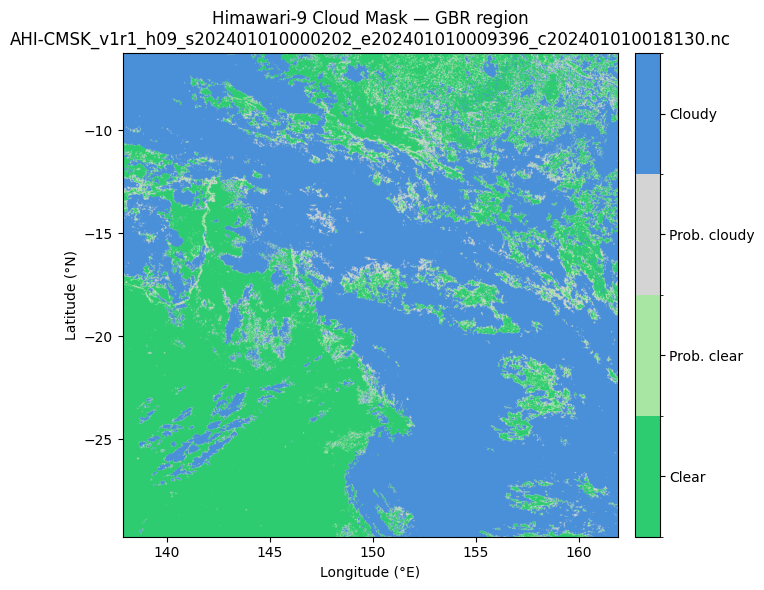

In [10]:
# ── Visualise the cloud mask ──────────────────────────────────────────────────

# Read geographic coordinates for axis labels
lat = ds_gbr["Latitude"].values
lon = ds_gbr["Longitude"].values
valid_lat = lat[lat > -900];  valid_lon = lon[lon > -900]

# Mask fill values (-128) as NaN for display
cm_display = cloud_mask.astype(float)
cm_display[cloud_mask < 0] = np.nan

cmap = mcolors.ListedColormap(["#2ecc71", "#a8e6a3", "#d4d4d4", "#4a90d9"])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(
    cm_display,
    cmap=cmap, norm=norm,
    extent=[valid_lon.min(), valid_lon.max(), valid_lat.min(), valid_lat.max()],
    origin="upper", aspect="equal",
)
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], pad=0.02)
cbar.set_ticklabels(["Clear", "Prob. clear", "Prob. cloudy", "Cloudy"])
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title(f"Himawari-9 Cloud Mask — GBR region\n{first_key.split('/')[-1]}")
plt.tight_layout()
plt.show()

---
## 6  Building a multi-file time-series collection

For a time series we need to combine N per-file references into a single virtual dataset indexed by
a `time` dimension.  This is a two-stage process:

### Stage A — Parallel reference generation

`build_references_parallel()` builds one kerchunk JSON reference per file.  By default each file's
HDF5 metadata is parsed independently from S3 (`SingleHdf5ToZarr`) — one S3 round-trip per file,
always correct, and cached to disk so subsequent queries are free.

An optional fast path is available via `templates_dir`: a pre-built product template reference is
used to derive all uncached references by URL substitution alone (zero S3 metadata calls).
**This mode assumes every file of the same product shares identical internal HDF5 chunk byte
offsets**, which is only true when zlib-compressed chunk sizes are uniform across files.

> **Warning — CHGT and CPHS are not safe for template-based generation.**
> These products contain continuous floating-point retrievals (cloud-top height, temperature,
> pressure, phase) whose compressed sizes vary significantly between scan times, so chunk byte
> offsets shift from file to file.  Using `templates_dir` for them produces references with wrong
> byte offsets that pass silently at reference-generation time and fail with a zlib decompression
> error only when data is actually downloaded (`Error -3 while decompressing data: incorrect
> header check`).
>
> If you see this error, delete the affected cached JSON refs and the combined Parquet store,
> then rerun without `templates_dir` to regenerate them from HDF5:
> ```bash
> find ~/.cache/himawari-gbr/refs -name 'AHI-CHGT*.json' -delete
> rm -rf ~/.cache/himawari-gbr/combined/CHGT_*
> ```

References already in the cache are always skipped regardless of mode.

### Stage B — MultiZarrToZarr → Parquet store

`build_combined_reference()` does three things:

1. **Expands** each per-file reference so that all `(Rows, Columns)` arrays become `(1, Rows, Columns)`.  
   This renames chunk keys `CloudMask/5.3 → CloudMask/0.5.3` and injects a scalar `time`
   coordinate (nanoseconds since epoch) extracted from the filename.

2. **Concatenates** all expanded references along the new `time` axis using  
   `kerchunk.combine.MultiZarrToZarr`.  `Latitude` and `Longitude` are declared as
   `identical_dims` (they never change) so only one copy is retained.

3. **Writes** the combined reference dict to a **Parquet store directory** via  
   `kerchunk.df.refs_to_dataframe()`.  This splits the ~100 K+ chunk references into
   per-variable `.parq` files that can be read lazily (no need to load all refs into RAM at once).

In [11]:
# Generate references for all 6 CMSK files in parallel.
# Only files not already cached will be fetched from S3.

ref_paths = build_references_parallel(
    cmsk_keys,
    CACHE_DIR,
    max_workers=4,
)

print(f"References ready: {len(ref_paths)}")
for p in ref_paths:
    print(f"  {p.name}  ({p.stat().st_size // 1024} KB)")

10:09:31  INFO     0/6 references need generating


References ready: 6
  AHI-CMSK_v1r1_h09_s202401010000202_e202401010009396_c202401010018130.json  (1944 KB)
  AHI-CMSK_v1r1_h09_s202401010010202_e202401010019396_c202401010028219.json  (1944 KB)
  AHI-CMSK_v1r1_h09_s202401010020202_e202401010029396_c202401010038223.json  (1944 KB)
  AHI-CMSK_v1r1_h09_s202401010030201_e202401010039395_c202401010049016.json  (1944 KB)
  AHI-CMSK_v1r1_h09_s202401010040201_e202401010049395_c202401010058071.json  (1944 KB)
  AHI-CMSK_v1r1_h09_s202401010050201_e202401010059395_c202401010108204.json  (1944 KB)


In [12]:
# Build the combined Parquet virtual store.  On first call this may take
# 20–60 s for 6 files (dominated by expanding + concatenating ~12 K references).
# Re-running the cell uses the cached store instantly.

store_dir = CACHE_DIR / "combined" / "CMSK_demo"

if not (store_dir / ".complete").exists():
    build_combined_reference(ref_paths, cmsk_keys, store_dir)
    (store_dir / ".complete").touch()
else:
    print(f"Using cached store: {store_dir}")

# Inspect what was written
parq_files = list(store_dir.rglob("*.parq"))
print(f"\nParquet store: {store_dir}")
print(f"  Subdirectories (one per variable): {len(list(store_dir.iterdir()))}")
print(f"  .parq files total:                 {len(parq_files)}")
print(f"  Total store size:                  {sum(f.stat().st_size for f in parq_files)//1024} KB")

Using cached store: /home/eklein/.cache/himawari-gbr/combined/CMSK_demo

Parquet store: /home/eklein/.cache/himawari-gbr/combined/CMSK_demo
  Subdirectories (one per variable): 38
  .parq files total:                 36
  Total store size:                  430 KB


---
## 7  Opening the combined virtual dataset

`open_virtual_dataset()` wires together:

```
LazyReferenceMapper(store_dir)          # reads .parq files for each accessed chunk key
    └──▶  ReferenceFileSystem(          # resolves [url, offset, length] → S3 byte-range
              remote_protocol="s3",
              remote_options={"anon": True},
          )
              └──▶  zarr mapper
                        └──▶  xr.open_dataset(..., engine="zarr", chunks={})
```

The `chunks={}` keyword makes every array Dask-backed.  The chunk size in Dask matches the
original HDF5 chunk size — `(1, 200, 200)` for time-series spatial arrays — giving Dask
fine-grained parallelism over individual S3 Range requests.

In [13]:
# Request only the scientific variables we need (skips AWIPS variants, etc.)
ds_ts = open_virtual_dataset(
    store_dir,
    variables=["CloudMask", "CloudProbability", "Latitude", "Longitude"],
)

print(ds_ts)
print()
print("time coordinate:", ds_ts.coords.get("time", "(not a coordinate — check data_vars)"))
print("time values    :", ds_ts["time"].values if "time" in ds_ts else "N/A")

<xarray.Dataset> Size: 2GB
Dimensions:           (time: 6, Rows: 5500, Columns: 5500)
Coordinates:
  * time              (time) datetime64[ns] 48B 2024-01-01 ... 2024-01-01T00:...
    Latitude          (Rows, Columns) float32 121MB dask.array<chunksize=(200, 200), meta=np.ndarray>
    Longitude         (Rows, Columns) float32 121MB dask.array<chunksize=(200, 200), meta=np.ndarray>
Dimensions without coordinates: Rows, Columns
Data variables:
    CloudMask         (time, Rows, Columns) float32 726MB dask.array<chunksize=(1, 200, 200), meta=np.ndarray>
    CloudProbability  (time, Rows, Columns) float32 726MB dask.array<chunksize=(1, 200, 200), meta=np.ndarray>
Attributes: (12/36)
    Conventions:                               CF-1.6
    ECM_LUT_NAME:                              v2.0/ecm2_abhi_ops_global_opt.nc
    ECM_PRIOR_NAME:                            v2.0/nb_cloud_mask_modis_prior...
    Metadata_Conventions:                      CF-1.6, Unidata Dataset Discov...
    Metadata_Lin

In [14]:
# Apply the GBR spatial subset — still no download
ds_ts_gbr = subset_to_gbr(ds_ts)

print("Time-series GBR Dataset:")
print(f"  Dims   : {dict(ds_ts_gbr.dims)}")
print(f"  Chunking of CloudMask: {ds_ts_gbr['CloudMask'].data.chunks}")

Time-series GBR Dataset:
  Dims   : {'time': 6, 'Rows': 1170, 'Columns': 1104}
  Chunking of CloudMask: ((1, 1, 1, 1, 1, 1), (105, 200, 200, 200, 200, 200, 65), (185, 200, 200, 200, 200, 119))


---
## 8  Computing and analysing the time series

With the subset in place we can compute one variable at a time, or use `dask.compute()` to
parallelise fetching multiple variables in a single pass.  Each `.compute()` call fetches only the
GBR chunks (~36 per variable per time step).

In [15]:
import dask

# Fetch CloudMask for all time steps in one parallel batch
t0 = time.perf_counter()
cm_ts = ds_ts_gbr["CloudMask"].compute().values   # shape: (N, 1170, 1104)
elapsed = time.perf_counter() - t0

print(f"Downloaded {cm_ts.shape[0]} time steps in {elapsed:.1f}s")
print(f"Array shape: {cm_ts.shape}  dtype: {cm_ts.dtype}")

Downloaded 6 time steps in 14.0s
Array shape: (6, 1170, 1104)  dtype: float32


In [16]:
# Compute per-time-step cloud fraction (prob. cloudy + cloudy, i.e. flag >= 2)
# Mask fill pixels (value = -128 after masking → NaN after mask_and_scale)

# ds uses mask_and_scale=True so fill values are already NaN if float, or
# the raw int8 fill is -128.  Let's work with the int8 directly.

time_values = ds_ts_gbr["time"].values   # numpy datetime64 array

cloud_fractions = []
for t in range(cm_ts.shape[0]):
    snap = cm_ts[t]
    valid = snap[snap >= 0]
    cf = (valid >= 2).mean()
    cloud_fractions.append(float(cf))

print("Time step       Cloud fraction")
print("-" * 34)
for t_val, cf in zip(time_values, cloud_fractions):
    print(f"  {str(t_val)[:16]}    {cf:.1%}")

Time step       Cloud fraction
----------------------------------
  2024-01-01T00:00    58.8%
  2024-01-01T00:10    59.3%
  2024-01-01T00:20    59.8%
  2024-01-01T00:30    60.3%
  2024-01-01T00:40    60.6%
  2024-01-01T00:50    60.7%


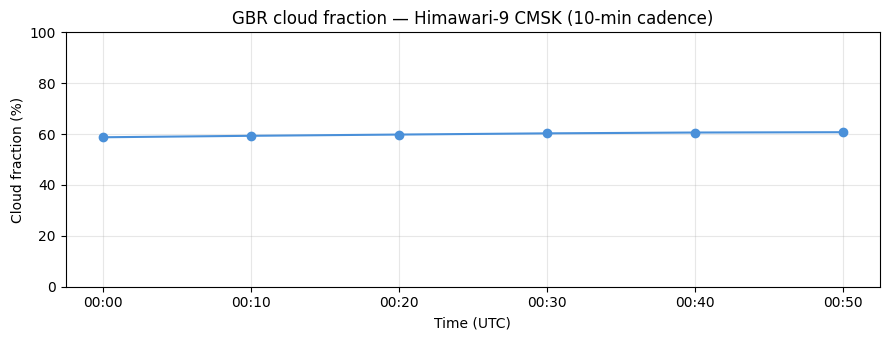

In [17]:
# ── Time-series plot ─────────────────────────────────────────────────────────

import matplotlib.dates as mdates

# Convert numpy datetime64 to Python datetimes for matplotlib
times_dt = [t.astype("datetime64[ms]").astype(datetime) for t in time_values]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(times_dt, [cf * 100 for cf in cloud_fractions],
        marker="o", color="#4a90d9", linewidth=1.5)
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Cloud fraction (%)")
ax.set_title("GBR cloud fraction — Himawari-9 CMSK (10-min cadence)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9  Working with multiple products

CHGT (cloud top height/temperature/pressure) and CPHS (cloud phase/type) share the same spatial
grid as CMSK.  After loading separately and applying `subset_to_gbr()`, xarray's `merge()` combines
them into a single Dataset along the shared `(time, Rows, Columns)` dimensions.

The `load_gbr_cloud_data()` high-level wrapper does this automatically (see Section 10).

In [18]:
# Load cloud-top height for the same time window
# (uses the same reference-generation and combine pipeline)

chgt_keys = list_product_files("CHGT", START, END)
chgt_refs = build_references_parallel(chgt_keys, CACHE_DIR, max_workers=4)

chgt_store = CACHE_DIR / "combined" / "CHGT_demo"
if not (chgt_store / ".complete").exists():
    build_combined_reference(chgt_refs, chgt_keys, chgt_store)
    (chgt_store / ".complete").touch()

ds_chgt = open_virtual_dataset(
    chgt_store,
    variables=["CldTopHght", "CldTopTemp", "CldTopPres", "CloudHgtQF"],
)
ds_chgt_gbr = subset_to_gbr(ds_chgt)

print("CHGT GBR dataset:")
print(ds_chgt_gbr)

10:09:57  INFO     0/6 references need generating
10:09:57  INFO     Expanding 6 references for time concatenation…
10:09:57  INFO     Running MultiZarrToZarr over 6 files…
10:11:16  INFO     Written Parquet store: /home/eklein/.cache/himawari-gbr/combined/CHGT_demo


CHGT GBR dataset:
<xarray.Dataset> Size: 134MB
Dimensions:     (time: 6, Rows: 1170, Columns: 1104)
Coordinates:
  * time        (time) datetime64[ns] 48B 2024-01-01 ... 2024-01-01T00:50:00
    Latitude    (Rows, Columns) float32 5MB dask.array<chunksize=(105, 185), meta=np.ndarray>
    Longitude   (Rows, Columns) float32 5MB dask.array<chunksize=(105, 185), meta=np.ndarray>
Dimensions without coordinates: Rows, Columns
Data variables:
    CldTopHght  (time, Rows, Columns) float32 31MB dask.array<chunksize=(1, 105, 185), meta=np.ndarray>
    CldTopTemp  (time, Rows, Columns) float32 31MB dask.array<chunksize=(1, 105, 185), meta=np.ndarray>
    CldTopPres  (time, Rows, Columns) float32 31MB dask.array<chunksize=(1, 105, 185), meta=np.ndarray>
    CloudHgtQF  (time, Rows, Columns) float32 31MB dask.array<chunksize=(1, 105, 185), meta=np.ndarray>
Attributes: (12/35)
    ACHA_Chn_Used:                             110_120_133
    Conventions:                               CF-1.6
    Metadat

In [19]:
# Merge CMSK and CHGT into a single Dataset along shared dimensions
# join='inner' keeps only time steps present in both products.
# Lat/Lon are dropped from ds_chgt_gbr before merging — they are identical
# to ds_ts_gbr (fixed geostationary grid) and the default xarray merge compat
# would otherwise download both copies from S3 just to verify equality.
ds_combined = xr.merge(
    [ds_ts_gbr, ds_chgt_gbr.drop_vars(["Latitude", "Longitude"], errors="ignore")],
    join="inner",
)

print("Merged Dataset:")
print(f"  Dims : {dict(ds_combined.dims)}")
print(f"  Vars : {list(ds_combined.data_vars)}")

Merged Dataset:
  Dims : {'time': 6, 'Rows': 1170, 'Columns': 1104}
  Vars : ['CloudMask', 'CloudProbability', 'CldTopHght', 'CldTopTemp', 'CldTopPres', 'CloudHgtQF']


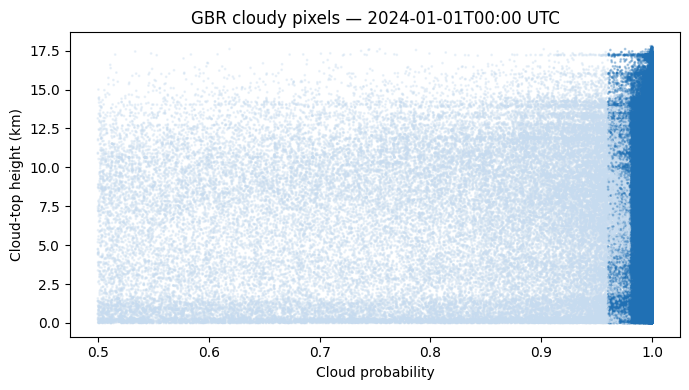

In [20]:
# Example: scatter plot of cloud probability vs. cloud-top height
# (for the first time step, cloudy pixels only)

t_idx = 0
cm  = ds_combined["CloudMask"].isel(time=t_idx).values
cp  = ds_combined["CloudProbability"].isel(time=t_idx).values
cth = ds_combined["CldTopHght"].isel(time=t_idx).values   # metres

# Select pixels flagged as cloudy or probably cloudy with valid height
mask = (cm >= 2) & (cth > 0)

fig, ax = plt.subplots(figsize=(7, 4))
sc = ax.scatter(
    cp[mask], cth[mask] / 1000,
    c=cm[mask], cmap="Blues", alpha=0.3, s=1,
    vmin=1.5, vmax=3.5,
)
ax.set_xlabel("Cloud probability")
ax.set_ylabel("Cloud-top height (km)")
ax.set_title(f"GBR cloudy pixels — {str(time_values[t_idx])[:16]} UTC")
plt.tight_layout()
plt.show()

---
## 10  High-level convenience wrapper: `load_gbr_cloud_data()`

For routine use the entire pipeline (list → reference → combine → open → subset) is wrapped in a
single call.  The function caches everything under `cache_dir` and uses a `.complete` sentinel file
to detect already-built stores, so re-running for the same time window is near-instant.

```
load_gbr_cloud_data(
    products,       # list of "CMSK" / "CHGT" / "CPHS"
    start_dt,       # datetime (UTC, inclusive)
    end_dt,         # datetime (UTC, inclusive)
    cache_dir,      # optional; defaults to ~/.cache/himawari-gbr
    max_workers,    # threads for parallel reference generation
    variables,      # optional override; uses PRODUCT_DATA_VARS defaults
    force_rebuild,  # discard and regenerate all cached files
) → xr.Dataset
```

The returned Dataset has dimensions `(time, Rows, Columns)` and no data has been downloaded yet —
it is fully lazy until you call `.compute()`.

In [21]:
# One call to get GBR cloud mask + cloud height for an hour of Himawari-9 data.
# Variables loaded per product (defaults from PRODUCT_DATA_VARS):
print("Default variables per product:")
for prod, varlist in PRODUCT_DATA_VARS.items():
    print(f"  {prod}: {varlist}")

Default variables per product:
  CMSK: ['CloudMask', 'CloudProbability', 'CloudMaskQualFlag']
  CHGT: ['CldTopHght', 'CldTopTemp', 'CldTopPres', 'CloudHgtQF']
  CPHS: ['CloudPhase', 'CloudType']


In [22]:
ds = load_gbr_cloud_data(
    products=["CMSK", "CHGT"],
    start_dt=datetime(2024, 1, 1,  0, 0),
    end_dt  =datetime(2024, 1, 1,  0, 50),
    max_workers=4,
)

print("\nReturned Dataset (lazy, no download yet):")
print(ds)

10:12:41  INFO     Processing CMSK  [2024-01-01T00:00:00 – 2024-01-01T00:50:00]
10:12:41  INFO     Found 6 CMSK files.
10:12:41  INFO     0/6 references need generating
10:12:41  INFO     Processing CHGT  [2024-01-01T00:00:00 – 2024-01-01T00:50:00]
10:12:41  INFO     Found 6 CHGT files.
10:12:41  INFO     0/6 references need generating
10:12:41  INFO     Expanding 6 references for time concatenation…
10:12:41  INFO     Running MultiZarrToZarr over 6 files…
10:13:57  INFO     Written Parquet store: /home/eklein/.cache/himawari-gbr/combined/CHGT_20240101T0000_20240101T0050



Returned Dataset (lazy, no download yet):
<xarray.Dataset> Size: 227MB
Dimensions:            (time: 6, Rows: 1170, Columns: 1104)
Coordinates:
  * time               (time) datetime64[ns] 48B 2024-01-01 ... 2024-01-01T00...
    Latitude           (Rows, Columns) float32 5MB dask.array<chunksize=(105, 185), meta=np.ndarray>
    Longitude          (Rows, Columns) float32 5MB dask.array<chunksize=(105, 185), meta=np.ndarray>
Dimensions without coordinates: Rows, Columns
Data variables:
    CloudMask          (time, Rows, Columns) float32 31MB dask.array<chunksize=(1, 105, 185), meta=np.ndarray>
    CloudProbability   (time, Rows, Columns) float32 31MB dask.array<chunksize=(1, 105, 185), meta=np.ndarray>
    CloudMaskQualFlag  (time, Rows, Columns) float32 31MB dask.array<chunksize=(1, 105, 185), meta=np.ndarray>
    CldTopHght         (time, Rows, Columns) float32 31MB dask.array<chunksize=(1, 105, 185), meta=np.ndarray>
    CldTopTemp         (time, Rows, Columns) float32 31MB dask.arr

In [23]:
# Compute one variable: cloud-top height for the second time step.
# Only the GBR chunks for that variable + time step are downloaded.

cth_snap = ds["CldTopHght"].isel(time=1).compute().values   # (1170, 1104), float32, metres

print(f"Cloud-top height shape: {cth_snap.shape}")
valid_cth = cth_snap[cth_snap > 0]
print(f"Valid cloudy pixels   : {valid_cth.size:,}")
print(f"Height range          : {valid_cth.min()/1000:.1f} – {valid_cth.max()/1000:.1f} km")
print(f"Mean cloud-top height : {valid_cth.mean()/1000:.2f} km")

Cloud-top height shape: (1170, 1104)
Valid cloudy pixels   : 732,340
Height range          : 0.0 – 17.8 km
Mean cloud-top height : 9.75 km


---
## 11  Cache structure and performance tips

### Cache layout

```
~/.cache/himawari-gbr/
│
├── refs/
│   └── AHI-L2-FLDK-Clouds/
│       └── 2024/01/01/0000/
│           ├── AHI-CMSK_v1r1_h09_s...json    ← per-file JSON reference (~2 MB each)
│           ├── AHI-CHGT_v1r1_h09_s...json
│           └── AHI-CPHS_v1r1_h09_s...json
│
└── combined/
    ├── CMSK_20240101T0000_20240101T0050/      ← Parquet store directory
    │   ├── .complete                          ← sentinel: build is complete
    │   ├── .zmetadata
    │   ├── CloudMask/refs.0.parq
    │   ├── CloudProbability/refs.0.parq
    │   └── …
    └── CHGT_20240101T0000_20240101T0050/
        └── …
```

### Tips for large collections

| Scenario | Recommendation |
|---|---|
| **First run** | Use `max_workers=8` for reference generation; this step is the bottleneck |
| **Repeat analysis** | Re-open the same `store_dir` with `open_virtual_dataset()` — no S3 metadata reads |
| **Many days of data** | Consider building one Parquet store per day and opening them with `xr.open_mfdataset()` |
| **Variable selection** | Always pass an explicit `variables` list to `open_virtual_dataset()` to avoid loading metadata for unused arrays |
| **Parallel compute** | Use `dask.compute(var1, var2, …)` to fetch multiple variables in one scheduler pass |
| **Cache disk space** | Per-file JSON references take ~2 MB each; a Parquet store for 6 files takes ~500 KB |

---
## 12  Re-deriving pixel bounds for a custom region

The default `GBR_ROW_SLICE` / `GBR_COL_SLICE` constants cover 142–155 °E, 10–25 °S with a
one-chunk (200 px) buffer.  If you need bounds for a different region call `compute_pixel_bounds()`.

This function reads the `Latitude` and `Longitude` arrays from a single reference file
(downloading only the overlapping chunks — roughly 10 MB), computes the mask, and returns a
`dict` of row/column minima and maxima.

In [24]:
# Example: Coral Sea extended region (lon 145–165 °E, lat 10–25 °S)
# (Uncomment to run — takes ~10 s to download the lat/lon chunks)

# bounds = compute_pixel_bounds(
#     first_key,
#     CACHE_DIR,
#     lon_range=(145.0, 165.0),
#     lat_range=(-25.0, -10.0),
#     buffer_chunks=1,
# )
# print("Coral Sea pixel bounds:", bounds)
# coral_sea_row = slice(bounds["row_min"], bounds["row_max"])
# coral_sea_col = slice(bounds["col_min"], bounds["col_max"])

# subset_to_gbr(ds, row_slice=coral_sea_row, col_slice=coral_sea_col)

print("Default GBR bounds for reference:")
print(f"  row_min={GBR_ROW_SLICE.start}, row_max={GBR_ROW_SLICE.stop}")
print(f"  col_min={GBR_COL_SLICE.start}, col_max={GBR_COL_SLICE.stop}")

Default GBR bounds for reference:
  row_min=3095, row_max=4265
  col_min=2615, col_max=3719


---
## Summary

```python
from datetime import datetime
from himawari_gbr.access import load_gbr_cloud_data

# One call — pipeline runs automatically, caches everything
ds = load_gbr_cloud_data(
    products=["CMSK", "CHGT", "CPHS"],
    start_dt=datetime(2024, 1, 1,  0, 0),
    end_dt  =datetime(2024, 1, 1, 23, 50),  # full day → 144 time steps
)

# Lazy — dims: (time=144, Rows=1170, Columns=1104)
# Downloads only on .compute()
cloud_mask = ds["CloudMask"].compute()    # ~80 MB for a full day
```

### Variables available per product

| Product | Variable | Description | Dtype |
|---|---|---|---|
| CMSK | `CloudMask` | 4-way flag (0=clear … 3=cloudy) | int8 |
| CMSK | `CloudProbability` | Bayesian cloud probability | float32 |
| CMSK | `CloudMaskQualFlag` | Quality flag | int8 |
| CHGT | `CldTopHght` | Cloud-top height (m) | float32 |
| CHGT | `CldTopTemp` | Cloud-top temperature (K) | float32 |
| CHGT | `CldTopPres` | Cloud-top pressure (hPa) | float32 |
| CHGT | `CloudHgtQF` | Quality flag | int8 |
| CPHS | `CloudPhase` | Cloud phase flag | int8 |
| CPHS | `CloudType` | Cloud type flag | int8 |
| All | `Latitude` | Pixel latitude (°N) | float32 |
| All | `Longitude` | Pixel longitude (°E) | float32 |